<a href="https://colab.research.google.com/github/Aninda2002/Cats-vs-Dogs-Classification/blob/main/cats_vs_dogs_classification_using_pre-trained_alexnet_and_vgg16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# ============================================================
# CATS vs DOGS CLASSIFICATION USING ALEXNET AND VGG16
# ============================================================

!pip install torch torchvision scikit-learn -q


In [ ]:
# =========================
# IMPORT LIBRARIES
# =========================
import os
import time
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
# =========================
# CHECK GPU
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

Using Device: cuda


In [ ]:

# ============================================================
# CONNECT GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# DATASET PATH
# ============================================================

# CHANGE PATH IF NEEDED

DATASET_PATH = "/content/drive/MyDrive/dataset/cats_and_dogs_small"

train_dir = os.path.join(DATASET_PATH, "train")
val_dir = os.path.join(DATASET_PATH, "validation")
test_dir = os.path.join(DATASET_PATH, "test")

print(train_dir)
print(val_dir)
print(test_dir)

/content/drive/MyDrive/dataset/cats_and_dogs_small/train
/content/drive/MyDrive/dataset/cats_and_dogs_small/validation
/content/drive/MyDrive/dataset/cats_and_dogs_small/test


In [ ]:
# ============================================================
# IMAGE TRANSFORMS
# ============================================================

train_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(15),

    transforms.RandomResizedCrop(
        224,
        scale=(0.8, 1.0)
    ),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

In [ ]:
# ============================================================
# LOAD DATASETS
# ============================================================

train_dataset = datasets.ImageFolder(
    train_dir,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    val_dir,
    transform=val_test_transform
)

test_dataset = datasets.ImageFolder(
    test_dir,
    transform=val_test_transform
)

print("Classes:", train_dataset.classes)


Classes: ['cats', 'dogs']


In [ ]:
# ============================================================
# DATALOADERS
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)


In [ ]:
# ============================================================
# TRAINING FUNCTION
# ============================================================

def train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        scheduler,
        epochs=25
):

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    train_acc_history = []
    val_acc_history = []

    for epoch in range(epochs):

        print(f"\nEpoch {epoch+1}/{epochs}")
        print("="*50)

        # =========================
        # TRAINING
        # =========================

        model.train()

        running_loss = 0.0
        running_corrects = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            _, preds = torch.max(outputs, 1)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item() * images.size(0)

            running_corrects += torch.sum(preds == labels.data)

            total += labels.size(0)

        epoch_loss = running_loss / total

        epoch_acc = running_corrects.double() / total

        train_acc_history.append(epoch_acc.cpu().numpy() * 100)

        # =========================
        # VALIDATION
        # =========================

        model.eval()

        val_corrects = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                _, preds = torch.max(outputs, 1)

                val_corrects += torch.sum(preds == labels.data)

                val_total += labels.size(0)

        val_acc = val_corrects.double() / val_total

        val_acc_history.append(val_acc.cpu().numpy() * 100)

        scheduler.step()

        print(f"Loss: {epoch_loss:.4f}")

        print(f"Train Accuracy: {epoch_acc*100:.2f}%")

        print(f"Validation Accuracy: {val_acc*100:.2f}%")

        # =========================
        # SAVE BEST MODEL
        # =========================

        if val_acc > best_acc:

            best_acc = val_acc

            best_model_wts = copy.deepcopy(
                model.state_dict()
            )

            print("Best Model Updated")

    print("\nTraining Complete")

    print(f"Best Validation Accuracy: {best_acc*100:.2f}%")

    model.load_state_dict(best_model_wts)

    return model, train_acc_history, val_acc_history

In [ ]:
# ============================================================
# EVALUATION FUNCTION
# ============================================================

def evaluate_model(model, test_loader):

    model.eval()

    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

            all_preds.extend(
                predicted.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    accuracy = 100 * correct / total

    print("\nTest Accuracy:", accuracy)

    print("\nClassification Report:\n")

    print(
        classification_report(
            all_labels,
            all_preds,
            target_names=['Cat', 'Dog']
        )
    )

    print("\nConfusion Matrix:\n")

    print(
        confusion_matrix(
            all_labels,
            all_preds
        )
    )

    return accuracy

In [ ]:
# ============================================================
# LOAD ALEXNET MODEL
# ============================================================

alexnet = models.alexnet(
    weights=models.AlexNet_Weights.IMAGENET1K_V1
)

# Freeze feature extractor
for param in alexnet.features.parameters():
    param.requires_grad = False

# Replace classifier
alexnet.classifier[6] = nn.Linear(4096, 2)

alexnet = alexnet.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    alexnet.parameters(),
    lr=0.0001
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)


In [ ]:
# ============================================================
# TRAIN ALEXNET
# ============================================================

print("\nTRAINING ALEXNET")

alexnet, alex_train_acc, alex_val_acc = train_model(

    alexnet,

    train_loader,

    val_loader,

    criterion,

    optimizer,

    scheduler,

    epochs=25
)


TRAINING ALEXNET

Epoch 1/25
Loss: 0.2346
Train Accuracy: 91.45%
Validation Accuracy: 93.00%
Best Model Updated

Epoch 2/25
Loss: 0.1281
Train Accuracy: 95.05%
Validation Accuracy: 95.60%
Best Model Updated

Epoch 3/25
Loss: 0.0912
Train Accuracy: 96.45%
Validation Accuracy: 95.20%

Epoch 4/25
Loss: 0.0688
Train Accuracy: 97.95%
Validation Accuracy: 95.10%

Epoch 5/25
Loss: 0.0689
Train Accuracy: 97.35%
Validation Accuracy: 96.10%
Best Model Updated

Epoch 6/25
Loss: 0.0487
Train Accuracy: 98.25%
Validation Accuracy: 95.80%

Epoch 7/25
Loss: 0.0486
Train Accuracy: 98.25%
Validation Accuracy: 95.70%

Epoch 8/25
Loss: 0.0389
Train Accuracy: 98.35%
Validation Accuracy: 95.50%

Epoch 9/25
Loss: 0.0326
Train Accuracy: 98.75%
Validation Accuracy: 96.10%

Epoch 10/25
Loss: 0.0258
Train Accuracy: 99.25%
Validation Accuracy: 95.30%

Epoch 11/25
Loss: 0.0278
Train Accuracy: 99.00%
Validation Accuracy: 95.80%

Epoch 12/25
Loss: 0.0332
Train Accuracy: 98.80%
Validation Accuracy: 95.30%

Epoch 13/

In [ ]:
# ============================================================
# TEST ALEXNET
# ============================================================

print("\nALEXNET TEST RESULTS")

alex_accuracy = evaluate_model(
    alexnet,
    test_loader
)


ALEXNET TEST RESULTS

Test Accuracy: 94.9

Classification Report:

              precision    recall  f1-score   support

         Cat       0.93      0.97      0.95       500
         Dog       0.96      0.93      0.95       500

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000


Confusion Matrix:

[[483  17]
 [ 34 466]]


In [ ]:
# ============================================================
# LOAD VGG16 MODEL
# ============================================================

vgg16 = models.vgg16(
    weights=models.VGG16_Weights.IMAGENET1K_V1
)

# Freeze convolution layers
for param in vgg16.features.parameters():
    param.requires_grad = False

# Replace classifier
vgg16.classifier[6] = nn.Linear(4096, 2)

vgg16 = vgg16.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    vgg16.parameters(),
    lr=0.00005
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)

In [ ]:
# ============================================================
# TRAIN VGG16
# ============================================================

print("\nTRAINING VGG16")

vgg16, vgg_train_acc, vgg_val_acc = train_model(

    vgg16,

    train_loader,

    val_loader,

    criterion,

    optimizer,

    scheduler,

    epochs=25
)


TRAINING VGG16

Epoch 1/25
Loss: 0.1288
Train Accuracy: 94.75%
Validation Accuracy: 98.70%
Best Model Updated

Epoch 2/25
Loss: 0.0360
Train Accuracy: 98.55%
Validation Accuracy: 98.10%

Epoch 3/25
Loss: 0.0355
Train Accuracy: 98.60%
Validation Accuracy: 98.80%
Best Model Updated

Epoch 4/25
Loss: 0.0217
Train Accuracy: 99.30%
Validation Accuracy: 98.80%

Epoch 5/25
Loss: 0.0201
Train Accuracy: 99.35%
Validation Accuracy: 98.70%

Epoch 6/25
Loss: 0.0179
Train Accuracy: 99.40%
Validation Accuracy: 98.30%

Epoch 7/25
Loss: 0.0134
Train Accuracy: 99.40%
Validation Accuracy: 98.40%

Epoch 8/25
Loss: 0.0082
Train Accuracy: 99.65%
Validation Accuracy: 98.70%

Epoch 9/25
Loss: 0.0064
Train Accuracy: 99.70%
Validation Accuracy: 98.70%

Epoch 10/25
Loss: 0.0046
Train Accuracy: 99.85%
Validation Accuracy: 98.60%

Epoch 11/25
Loss: 0.0052
Train Accuracy: 99.90%
Validation Accuracy: 98.70%

Epoch 12/25
Loss: 0.0074
Train Accuracy: 99.80%
Validation Accuracy: 98.40%

Epoch 13/25
Loss: 0.0092
Train

In [ ]:
# ============================================================
# TEST VGG16
# ============================================================

print("\nVGG16 TEST RESULTS")

vgg_accuracy = evaluate_model(
    vgg16,
    test_loader
)


VGG16 TEST RESULTS

Test Accuracy: 98.7

Classification Report:

              precision    recall  f1-score   support

         Cat       0.98      0.99      0.99       500
         Dog       0.99      0.98      0.99       500

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000


Confusion Matrix:

[[497   3]
 [ 10 490]]


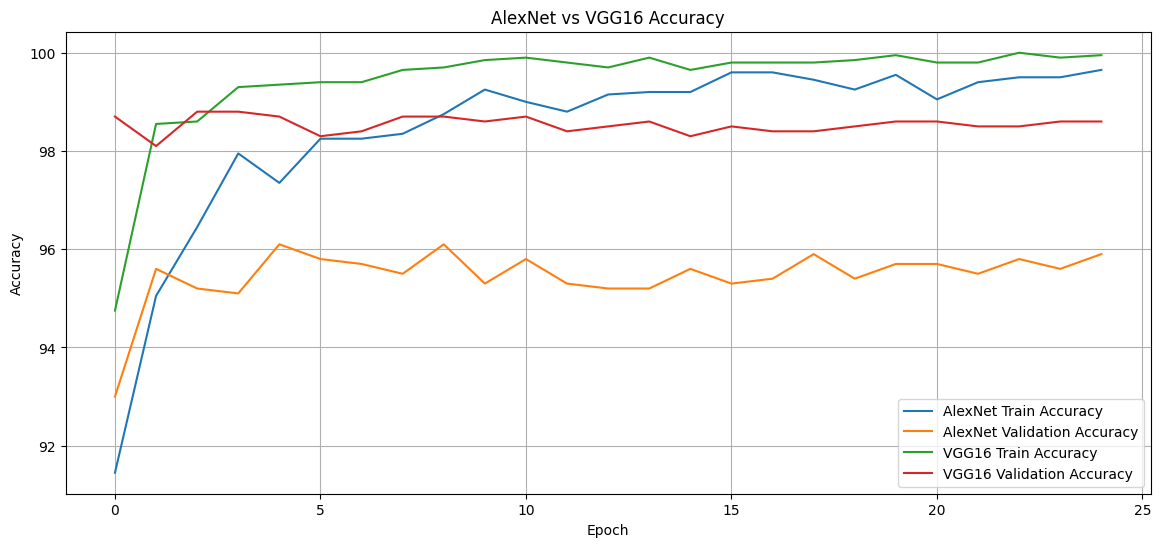

In [ ]:
# ============================================================
# PLOT ACCURACY
# ============================================================

plt.figure(figsize=(14,6))

plt.plot(
    alex_train_acc,
    label="AlexNet Train Accuracy"
)

plt.plot(
    alex_val_acc,
    label="AlexNet Validation Accuracy"
)

plt.plot(
    vgg_train_acc,
    label="VGG16 Train Accuracy"
)

plt.plot(
    vgg_val_acc,
    label="VGG16 Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title(
    "AlexNet vs VGG16 Accuracy"
)

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# ============================================================
# SAVE MODELS
# ============================================================

torch.save(
    alexnet.state_dict(),
    "/content/drive/MyDrive/alexnet_cats_dogs.pth"
)

torch.save(
    vgg16.state_dict(),
    "/content/drive/MyDrive/vgg16_cats_dogs.pth"
)

print("\nModels Saved Successfully")


Models Saved Successfully


In [ ]:
# ============================================================
# FINAL RESULTS
# ============================================================

print("\nFINAL RESULTS")
print("="*50)

print(f"AlexNet Accuracy : {alex_accuracy:.2f}%")

print(f"VGG16 Accuracy   : {vgg_accuracy:.2f}%")


FINAL RESULTS
AlexNet Accuracy : 94.90%
VGG16 Accuracy   : 98.70%


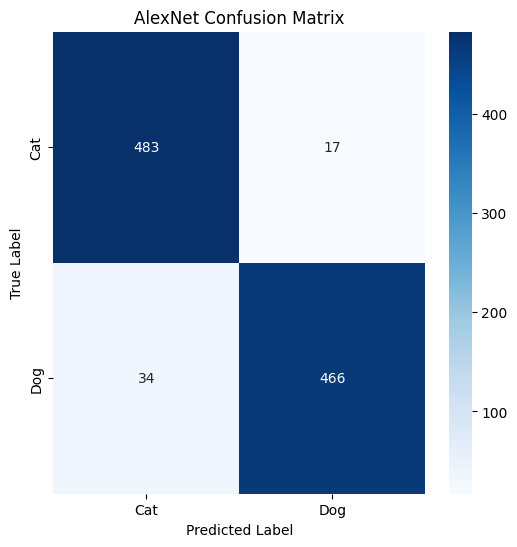

In [ ]:
# ============================================================
# CONFUSION MATRIX PLOT FOR ALEXNET
# ============================================================

import seaborn as sns

alexnet.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = alexnet(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())

        all_labels.extend(labels.cpu().numpy())

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(all_labels, all_preds)

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Cat', 'Dog'],
    yticklabels=['Cat', 'Dog']
)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title("AlexNet Confusion Matrix")

plt.show()

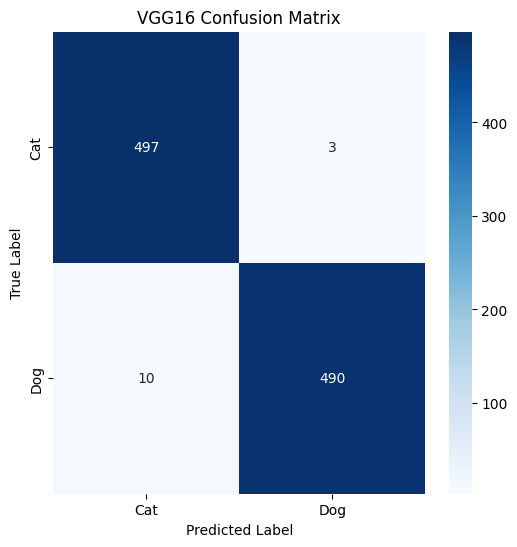

In [ ]:
# ============================================================
# CONFUSION MATRIX PLOT FOR VGG16
# ============================================================

import seaborn as sns

vgg16.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = vgg16(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())

        all_labels.extend(labels.cpu().numpy())

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(all_labels, all_preds)

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Cat', 'Dog'],
    yticklabels=['Cat', 'Dog']
)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title("VGG16 Confusion Matrix")

plt.show()